(ch:foundations)=
# 3. Mathematical foundations: from sample spaces to Bayes' theorem

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* work with sample spaces, events and the basic rules of probability (addition rule, product rule);
* derive Bayes' theorem from the definition of conditional probability, and name each of its terms;
* state and prove the law of total probability, and explain how it becomes *marginalization* over a nuisance parameter;
* explain where the likelihood of a dataset comes from, and what the difference between the frequentist and Bayesian interpretation of probability is.

This chapter accompanies the second and third part of Lecture 2. It is the most mathematical chapter of these notes, and deliberately short: the point is not the set theory but the three rules that everything else in this course is built on.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

plt.rcParams["figure.figsize"] = (7, 4.5)

## 3.1 Deductive and inductive logic

In mathematics and classical mechanics we reason *deductively*: from true premises to certain conclusions. Data analysis is different. We observe a finite, noisy dataset and want to reason back to the cause: which model, which parameter values? This is *inductive* logic, or *plausible reasoning* (Sivia & Skilling 2006). Probability theory is the calculus of plausible reasoning: it tells us how to update what we believe when we get new information, in a way that is consistent and quantitative. In this chapter we set up the small amount of formalism needed.

## 3.2 Sample spaces and events

```{admonition} Definitions
:class: note
* The **sample space** $\Omega$ is the set of all possible, mutually exclusive outcomes of an experiment. By definition $P(\Omega) = 1$.
* Elements $\omega \in \Omega$ are called **outcomes**.
* A subset $A \subset \Omega$ is called an **event**. The probability $P(A)$ is a number between 0 and 1 assigned to every event.
```

Two coin tosses have the sample space $\Omega = \{HH, HT, TH, TT\}$ with four equally probable outcomes. "At least one head" is the event $\{HH, HT, TH\}$ with probability $3/4$.

For two events $A$ and $B$ we define:

* the **complement** $A^c$ (also written $\neg A$ or "not $A$"): all outcomes not in $A$;
* the **union** $A \cup B$ ("$A$ or $B$"): outcomes in $A$, in $B$, or in both (the "or" is inclusive);
* the **intersection** $A \cap B$ ("$A$ and $B$", also written $A, B$): outcomes in both;
* the **difference** $A \setminus B$ ("$A$ but not $B$").

Venn diagrams are the natural way to picture these. The rectangle is $\Omega$ and the total shaded area is the probability of the event.

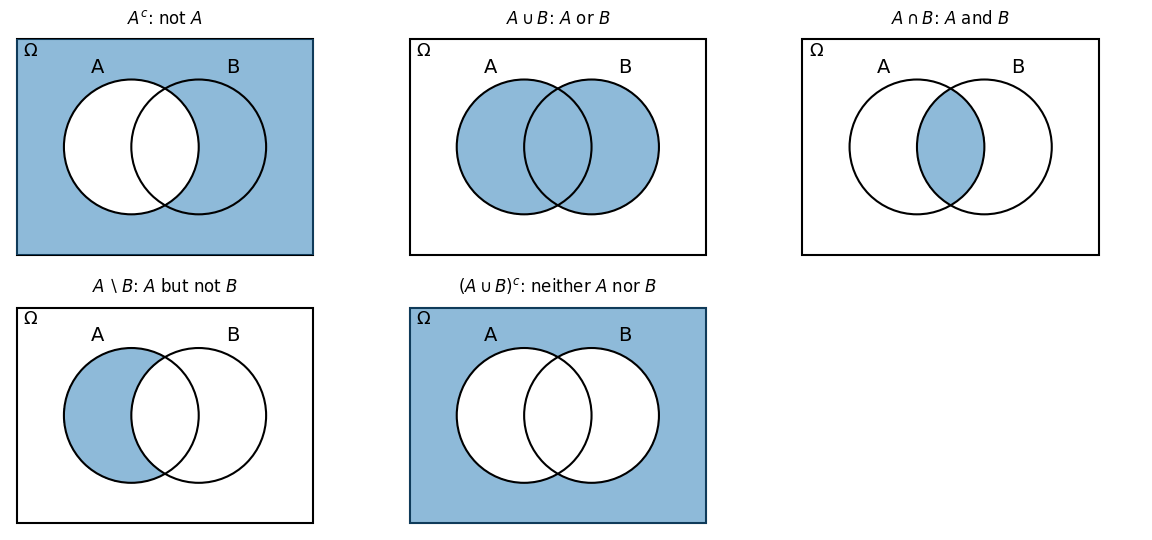

In [2]:
def venn(ax, shade, title):
    """draw two overlapping circles A and B inside Omega and shade a region"""
    A, B = Circle((-0.5, 0), 1.0), Circle((0.5, 0), 1.0)
    ax.add_patch(Rectangle((-2.2, -1.6), 4.4, 3.2, fc="white", ec="k", lw=1.5))
    # shade by drawing on a fine grid
    xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 400), np.linspace(-1.6, 1.6, 300))
    inA = (xx + 0.5)**2 + yy**2 < 1; inB = (xx - 0.5)**2 + yy**2 < 1
    mask = {"not A": ~inA, "A or B": inA | inB, "A and B": inA & inB,
            "A but not B": inA & ~inB, "not (A or B)": ~(inA | inB)}[shade]
    ax.contourf(xx, yy, mask.astype(float), levels=[0.5, 1.5], colors=["C0"], alpha=0.5)
    for c, lab, x0 in [(A, "A", -1.0), (B, "B", 1.0)]:
        c.set(fc="none", ec="k", lw=1.5); ax.add_patch(c); ax.text(x0, 1.1, lab, fontsize=14, ha="center")
    ax.text(-2.1, 1.35, r"$\Omega$", fontsize=13)
    ax.set_xlim(-2.3, 2.3); ax.set_ylim(-1.7, 1.7); ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)

fig, axs = plt.subplots(2, 3, figsize=(12, 5.5))
for ax, (shade, title) in zip(axs.flat, [("not A", r"$A^c$: not $A$"), ("A or B", r"$A\cup B$: $A$ or $B$"),
                                          ("A and B", r"$A\cap B$: $A$ and $B$"), ("A but not B", r"$A\setminus B$: $A$ but not $B$"),
                                          ("not (A or B)", r"$(A\cup B)^c$: neither $A$ nor $B$")]):
    venn(ax, shade, title)
axs.flat[-1].axis("off")
plt.tight_layout()

**Example.** In the two-coin experiment let $A = \{HH, HT\}$ (first toss is heads) and $B = \{HH, TT\}$ (both tosses equal). Then $A\cap B = \{HH\}$ with $P = 1/4$, $A\cup B = \{HH, HT, TT\}$ with $P=3/4$, and "neither $A$ nor $B$" $=\{TH\}$ with $P=1/4$.

## 3.3 The rules of probability

### The axioms

Kolmogorov (1933) defined probability as a function $P$ that assigns a number to every event and satisfies three axioms:

1. $P(A) \geq 0$ for every event $A$;
2. $P(\Omega) = 1$;
3. if $A_1, A_2, \dots$ are mutually exclusive (disjoint: no two of them can happen together), then $P(A_1 \cup A_2 \cup \dots) = P(A_1) + P(A_2) + \dots$

Everything else follows from these, for example $P(A^c) = 1 - P(A)$ (apply axiom 3 to $A$ and $A^c$, then axiom 2) and $0 \leq P(A) \leq 1$. Note that the axioms do not say what a probability *means*; both the frequency interpretation and the degree-of-belief interpretation (Section 3.6) satisfy them.

Everything in this course follows from the axioms via three rules.

### The addition rule

$$
P(A \cup B) = P(A) + P(B) - P(A\cap B) .
$$ (eq:addition)

The overlap is counted twice in $P(A) + P(B)$, so it is subtracted once (the *inclusion–exclusion principle*). For *mutually exclusive* events ($A\cap B = \emptyset$) the probabilities simply add, which is axiom 3. Check it on the coin example: $3/4 = 1/2 + 1/2 - 1/4$.

```{admonition} Proof of the addition rule (click to show)
:class: note dropdown
The union can be cut into three disjoint pieces (look at the Venn diagram): $A\cup B = (A\setminus B)\cup(A\cap B)\cup(B\setminus A)$. By axiom 3,

$$
P(A\cup B) = P(A\setminus B) + P(A\cap B) + P(B\setminus A) .
$$

Also by axiom 3, $A$ is the disjoint union of $A\setminus B$ and $A\cap B$, so $P(A\setminus B) = P(A) - P(A\cap B)$, and likewise $P(B\setminus A) = P(B) - P(A\cap B)$. Substituting both gives $P(A\cup B) = P(A) + P(B) - P(A\cap B)$. (After Wasserman 2004, Theorem 1.11.)
```

### The product rule and conditional probability

The **conditional probability** of $A$ given that $B$ has happened is written $P(A\,|\,B)$ and defined as

$$
P(A\,|\,B) = \frac{P(A\cap B)}{P(B)} .
$$ (eq:conditional)

Geometrically: knowing that $B$ happened shrinks the sample space to the circle $B$, and $P(A\,|\,B)$ is the fraction of the area of $B$ that is covered by $A$. Rearranged, this is the **product rule**,

$$
P(A\cap B) = P(A\,|\,B)\,P(B) = P(B\,|\,A)\,P(A) .
$$ (eq:product)

Two events are **independent** if knowing $B$ tells you nothing about $A$: $P(A\,|\,B) = P(A)$, and hence $P(A\cap B) = P(A)P(B)$.

Be precise about *what* you condition on. $P(A\,|\,B)$ and $P(B\,|\,A)$ are different numbers (the probability that a randomly chosen astronomer is Dutch is not the probability that a randomly chosen Dutch person is an astronomer), and the answer to a probability puzzle usually hinges on exactly which information is taken as given. The Monty Hall problem of the tutorial is the classic exercise in this: the host's choice of which door to open is itself information, and it must be conditioned on.

```{admonition} Where the likelihood comes from
:class: important
Suppose our dataset consists of two observations, $y = \{y_1, y_2\}$. Think of "$y_1$ has the value we observed" as event $A$ and likewise $y_2$ as $B$. The probability of the dataset is then

$$
P(y_1, y_2) = P(y_2\,|\,y_1)\,P(y_1) = P(y_1)\,P(y_2) \quad \text{if the observations are independent.}
$$

Repeating this for $N$ independent data points, and making the dependence on the model parameters explicit, we recover the likelihood of Chapter 1,

$$
\mathcal{L}(\theta) = p(y\,|\,\theta) = \prod_{i=1}^{N} p(y_i\,|\,\theta) .
$$

So the product in the likelihood is nothing but the product rule plus the assumption of independence. When data points are *not* independent (correlated noise), the product must be replaced by a joint probability density, e.g. a multivariate Gaussian with a non-diagonal covariance matrix.
```

### The law of total probability (marginalization)

Let $\{A_1, \dots, A_k\}$ be a set of mutually exclusive events that together cover the whole sample space (exactly one of them happens). Then for any event $B$,

$$
P(B) = \sum_{i=1}^{k} P(B\cap A_i) = \sum_{i=1}^{k} P(B\,|\,A_i)\,P(A_i) .
$$ (eq:total-probability)

In words: to get the probability of $B$, sum over all the different ways in which $B$ can happen. The second form follows from the product rule.

**Discrete example.** A drawer contains batteries, 20% of brand D and 80% of brand P. Of the D batteries 50% are charged, of the P batteries 20%. The probability that a randomly picked battery is charged is $P(\text{charged}) = 0.5\times0.2 + 0.2\times0.8 = 0.26$.

**Continuous version.** If the "events" are the values of a continuous variable $\theta_2$ with probability density $p(\theta_2)$, the sum becomes an integral:

$$
P(B) = \int P(B\,|\,\theta_2)\,p(\theta_2)\,d\theta_2 .
$$

In parameter inference we use this constantly. Suppose our model has two parameters and we have obtained the joint posterior probability density $p(\theta_1, \theta_2\,|\,y)$ (Chapter {ref}`4 <ch:inference>` explains how). If we only care about $\theta_1$, we **marginalize** over $\theta_2$:

$$
p(\theta_1\,|\,y) = \int_{-\infty}^{\infty} p(\theta_1, \theta_2\,|\,y)\,d\theta_2 .
$$ (eq:marginalization)

The parameter $\theta_2$ is then called a **nuisance parameter**: we need it in the model but we are not interested in its value. Examples: the unknown intrinsic scatter of a relation, the calibration offset of an instrument, the absolute magnitude $M$ of a standard candle when we want the distance $d$ from an apparent magnitude $m$ (the posterior for $d$ is $\int p(d, M\,|\,m)\,dM$; a frequentist who fixes $M$ at its mean value will underestimate the uncertainty on $d$). Marginalization is the single biggest practical advantage of the Bayesian approach, and the reason we will need priors.

## 3.4 Bayes' theorem

```{admonition} Derivation (from the board in Lecture 2)
:class: note
By the definition of conditional probability, $P(A\,|\,B) = P(A\cap B)/P(B)$. The intersection is symmetric, $A\cap B = B\cap A$, so the same definition with the roles of $A$ and $B$ swapped gives $P(A\cap B) = P(B\,|\,A)\,P(A)$. Substituting the second expression into the first:

$$
P(A\,|\,B) = \frac{P(B\,|\,A)\,P(A)}{P(B)} .
$$ (eq:bayes)

The denominator is usually evaluated with the law of total probability, $P(B) = P(B\,|\,A)P(A) + P(B\,|\,A^c)P(A^c)$.
```

That is all: **Bayes' theorem is the product rule read backwards.** Its power appears when $A$ is a *hypothesis* (or a parameter value) and $B$ is the *data*: the theorem converts the probability of the data given the hypothesis (which the generative model provides) into the probability of the hypothesis given the data (which is what we want).

**Example: a rare disease.** One in a thousand people has a disease. A test detects it in 99% of the cases, but also gives a positive result for 5% of the healthy people. You test positive. What is the probability that you have the disease?

In [3]:
P_D = 0.001            # prior: P(disease)
P_pos_D = 0.99         # P(positive | disease)
P_pos_notD = 0.05      # P(positive | no disease)

P_pos = P_pos_D * P_D + P_pos_notD * (1 - P_D)      # law of total probability
P_D_pos = P_pos_D * P_D / P_pos                     # Bayes' theorem
print(f"P(disease | positive test) = {P_D_pos:.3f}")

P(disease | positive test) = 0.019


Only 2%: the false positives among the 999 healthy people vastly outnumber the true positives. The same calculation applies to classifying astronomical sources (is this variable star a Cepheid, given its period?), where the *base rate* $P(A)$ of the rare class is the decisive ingredient.

### The terms of Bayes' theorem for parameter inference

Writing $\theta$ for the model parameters and $y$ for the data, and using $p(\cdot)$ for probability *densities*,

$$
\underbrace{p(\theta\,|\,y)}_{\text{posterior}} = \frac{\overbrace{p(y\,|\,\theta)}^{\text{likelihood}}\;\overbrace{p(\theta)}^{\text{prior}}}{\underbrace{p(y)}_{\text{evidence}}} .
$$ (eq:bayes-parameters)

* The **posterior** $p(\theta\,|\,y)$ is our goal: the probability distribution of the parameters given the data.
* The **likelihood** $p(y\,|\,\theta)$ is the probability of the data given the parameters; it follows from the generative model (Chapter 1).
* The **prior** $p(\theta)$ encodes what we know about the parameters *before* seeing the data (Chapter {ref}`5 <ch:priors>`). Often we use a constant ("flat", non-informative) prior.
* The **evidence** $p(y) = \int p(y\,|\,\theta)\,p(\theta)\,d\theta$ is the normalization, obtained with the law of total probability. It does not depend on $\theta$, so for parameter inference we usually write $p(\theta\,|\,y) \propto p(y\,|\,\theta)\,p(\theta)$ and normalize at the end (grid methods) or not at all (MCMC, Chapter {ref}`6 <ch:mcmc>`).

In words: *posterior $\propto$ likelihood $\times$ prior*, or *prob(hypothesis | data) $\propto$ prob(data | hypothesis) $\times$ prob(hypothesis)*.

```{admonition} Notation: where do $x$, $\sigma_y$ and "I" go?
:class: note
Different sources write the same theorem in different ways.

* These notes and the lectures: $p(\theta\,|\,y) \propto p(y\,|\,\theta)\,p(\theta)$.
* Gelman et al. (2013), Eq. 1.2: $p(\theta\,|\,y) \propto p(\theta)\,p(y\,|\,\theta)$, prior first.
* Many statistics textbooks (e.g. Wasserman 2004): $f(\theta\,|\,x^n) \propto \mathcal{L}_n(\theta)\,\pi(\theta)$, with $f$ for densities, $\pi$ for the prior and $x^n = (x_1,\dots,x_n)$ for the data.
* Hogg et al. (2010), Eq. 12: $p(\theta\,|\,\{y_i\}_{i=1}^N, I) \propto p(\{y_i\}_{i=1}^N\,|\,\theta, I)\,p(\theta\,|\,I)$, where $I$ stands for all *background information*: the independent variables $x_i$, the uncertainties $\sigma_{y,i}$, the choice of model, and everything else we take as given.

When we fit $y$ as a function of $x$, the $x_i$ are part of the experimental design and have no uncertainty, and the $\sigma_{y,i}$ are known. Both are conditioned on everywhere, so the fully explicit version is $p(\theta\,|\,y, x, \sigma_y) \propto p(y\,|\,\theta, x, \sigma_y)\,p(\theta)$. In practice we absorb them in $I$ or drop them from the notation, but remember that they are there: the likelihood is a probability of $y$ only.
```

## 3.5 Random variables

The sample space is an abstract set; data are numbers. A **random variable** $Y$ is a function that assigns a real number $Y(\omega)$ to every outcome $\omega \in \Omega$ (e.g. "the number of heads"). Its **probability density function** (PDF) $p(y)$ is defined such that $p(y)\,dy$ is the probability that $Y$ falls in $[y, y+dy]$; for a discrete variable it is a probability mass function, e.g. the Poisson distribution of Chapter 1. We then view the data $y_1, \dots, y_N$ as $N$ realizations of the random variable $Y$, and in practice we work with the PDF and forget about the sample space. Everything in Sections 3.3 and 3.4 carries over from events to random variables, with sums replaced by integrals where the variables are continuous. (Some books call random variables "variates"; we will not.)

## 3.6 Frequentists and Bayesians

The two schools disagree about what a probability *is*.

* For a **frequentist**, probability is the long-run relative frequency of an outcome in infinitely many repetitions of the same experiment. Probabilities can be assigned to *data* (which are random), but not to *hypotheses* or *parameters*: the mass of Saturn is a fixed number, not a random variable, so a statement like "the probability that the mass of Saturn is between $a$ and $b$" is meaningless. Hence the somewhat contorted definition of the confidence interval in Chapter 1: it is the interval that is random, not the parameter.
* For a **Bayesian**, probability is a *degree of belief* (or degree of certainty), and can be assigned to anything, including parameters and hypotheses. Laplace, who rediscovered Bayes' theorem independently in 1774 (Bayes' own essay was published posthumously in 1763), used it to estimate the mass of Saturn from orbital data and announced that "it is a bet of 11,000 to 1 that the error of this result is not 1/100th of its value". 150 years later the accepted value had changed by 0.63%. He also applied it to medical statistics and even jurisprudence.

Twentieth-century statisticians (Fisher, Neyman, Pearson) found degrees of belief too vague and priors too subjective, and built the frequentist edifice of estimators, tests and confidence intervals that dominated until computers made Bayesian calculations practical in the 1980s and 1990s. Today both are in use, often side by side; the debates can be passionate, but for large datasets the two approaches usually agree, and many frequentist methods can be understood as Bayesian inference with a particular (implicit) prior.

For this course the practical differences are:

1. Bayesians can make probabilistic statements about parameters ("the credible interval"), frequentists cannot.
2. Bayesians must specify a prior, which is a nuisance in simple problems but a *necessity* for marginalization: an integral over a parameter needs a measure, and the prior provides it (Hogg et al. 2010).
3. Prior information (a previous experiment, a physical constraint like "the mass is positive") enters naturally in the Bayesian framework.

The remaining chapters of these notes follow the Bayesian route.

## 3.7 Test yourself

````{admonition} Q1. Derive Bayes' theorem (exam 2025)
:class: tip
Use the relation of conditional probability, $p(A\,|\,B) = p(A,B)/p(B)$, to derive Bayes' theorem.

```{admonition} Answer
:class: dropdown
The definition gives $p(A,B) = p(A\,|\,B)\,p(B)$. Because $p(A,B) = p(B,A)$, the same definition with the roles swapped gives $p(A,B) = p(B\,|\,A)\,p(A)$. Equating the two and dividing by $p(B)$: $p(A\,|\,B) = p(B\,|\,A)\,p(A)/p(B)$.
```
````

````{admonition} Q2. Which way round?
:class: tip
A survey shows that 60% of the sources in a catalogue are galaxies and 40% are stars. Of the galaxies, 80% are extended in the images; of the stars, 5% appear extended (because of blending). A source is extended. Someone concludes "there is an 80% probability that it is a galaxy". Explain what is wrong, and compute the correct probability.

```{admonition} Answer
:class: dropdown
The 80% is $P(\text{extended}\,|\,\text{galaxy})$, but the question asks for $P(\text{galaxy}\,|\,\text{extended})$; the two are related by Bayes' theorem, not equal. With the law of total probability, $P(\text{extended}) = 0.8\times0.6 + 0.05\times0.4 = 0.50$, so $P(\text{galaxy}\,|\,\text{extended}) = 0.8\times0.6/0.50 = 0.96$. Here the base rate helps the conclusion; in the rare-disease example it destroyed it.
```
````

````{admonition} Q3. Marginalization in practice (exam 2025)
:class: tip
The previous result generalizes to $p(\theta_1\,|\,y) = \int d\theta_2\, p(\theta_1, \theta_2\,|\,y)$. Give an example when this relation is used in data analysis.

```{admonition} Answer
:class: dropdown
Any nuisance parameter. For example: we fit a straight line and also include the unknown intrinsic scatter $\epsilon$ as a parameter; to report the posterior of the slope alone we integrate the joint posterior over $\epsilon$. Or: to get the posterior of the distance to a star from its apparent magnitude we integrate over the uncertain absolute magnitude. In MCMC, marginalization is automatic: the histogram of the samples of $\theta_1$ *is* the marginal posterior.
```
````

## Sources and further reading

* Gelman et al. (2013), *Bayesian Data Analysis* (3rd ed.), [free PDF](https://sites.stat.columbia.edu/gelman/book/BDA3.pdf), Sections 1.1–1.8.
* Sivia & Skilling (2006), *Data Analysis: A Bayesian Tutorial*, Oxford University Press, Chapter 1, for the deductive/inductive picture and the history.
* Wasserman (2004), *All of Statistics*, Springer, Chapters 1–2, for the axioms and formal proofs of the rules of probability.
* Uttley, [*Statistical methods for astrophysics*](https://philuttley.github.io/stats-methods-24/), for the Venn-diagram approach used in the lecture.
* Bayes (1763), *An essay towards solving a problem in the doctrine of chances*, Phil. Trans. R. Soc. 53, 370, [doi:10.1098/rstl.1763.0053](https://doi.org/10.1098/rstl.1763.0053), the original.
* McGrayne (2011), *The Theory That Would Not Die*, Yale University Press, for the full history of Bayes, Price and Laplace.